In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [13]:
df=pd.read_csv("height-weight.csv")

In [14]:
df.head()

,weight,height
0,35,120
1,37,126
2,40,142
3,41,143
4,45,130


Text(0, 0.5, 'Height')

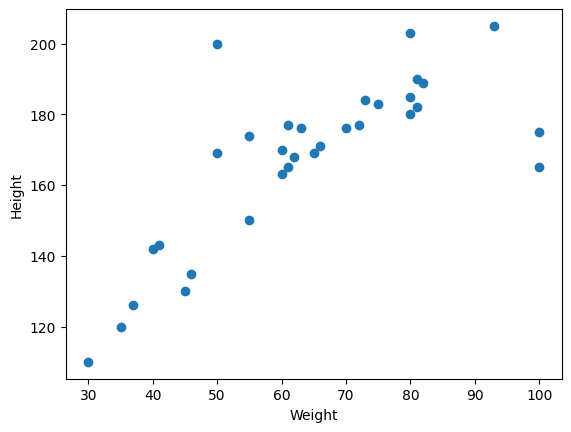

In [15]:
##scatter plot
plt.scatter(df['weight'],df['height'])
plt.xlabel("Weight")
plt.ylabel("Height")


In [16]:
## Correlation
df.corr()

,weight,height
weight,1.000000,0.756114
height,0.756114,1.000000


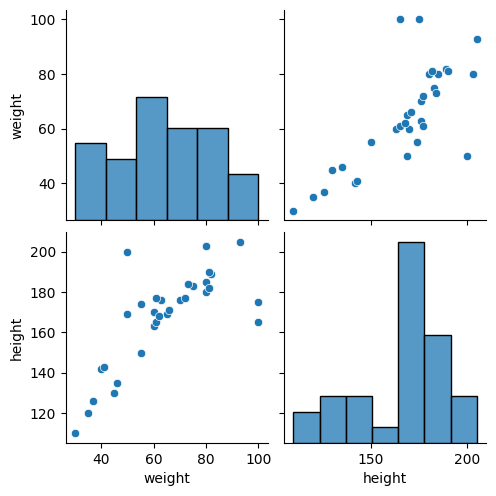

In [18]:
## Seaborn for implementation
import seaborn as sns
sns.pairplot(df)


In [34]:
## Independent and dependent
X=df[['weight']] ##Independent feature should be in the form of Data frame or 2D array
X.head()

,weight
0,35
1,37
2,40
3,41
4,45


In [39]:
y=df['height'] ## Dependent should be in series or in one dimension array
y.head()

0    120
1    126
2    142
3    143
4    130
Name: height, dtype: int64

In [40]:
## Train test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [41]:
X_train.shape

(24, 1)

In [44]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [47]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [48]:
X_test=scaler.transform(X_test)

In [49]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [ ]:
regression=LinearRegression(n_jobs=-1)#n_jobs=-1 will allow to use all processors

In [54]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [16.26528227]
Intercept: 166.66666666666666


Coefficient being 16.26 means one unit movement in weight value will change height by that much and with the base offset of intercept i.e. 166.67

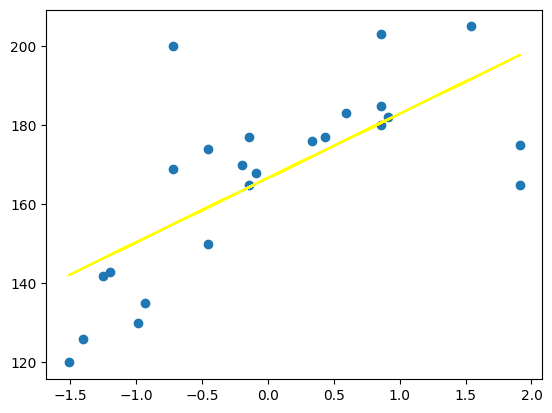

In [62]:
## plot Training data best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"yellow")

### Prediction

1. predicted height output = intercept + coef_(weights)
2. y_pred_test=166.66666666666666 + 16.26528227(weights)

In [64]:
## Prediction for test data
y_pred=regression.predict(X_test)

In [65]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [69]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


135.5580927033796
8.301514699585795
11.642941754701841


### R Square

R ^ 2 = 1 - SSR/SST

In [70]:
from sklearn.metrics import r2_score

In [72]:
score=r2_score(y_test,y_pred)
print(score)

0.7660774931779472


### Adjusted R^2

In [73]:
# display adjusted r-square
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7270904087076051

In [74]:
## OLS Technique
import statsmodels.api as sm

In [75]:
model=sm.OLS(y_train,X_train).fit()

In [77]:
prediction=model.predict(X_test)
prediction

array([ 15.66165054,  -0.60648761,   1.10594799,   7.95569037,
        -3.175141  , -28.86167492,  14.80543274,   1.96216579])

In [79]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 height   R-squared (uncentered):                   0.009
Model:                            OLS   Adj. R-squared (uncentered):             -0.034
Method:                 Least Squares   F-statistic:                             0.2169
Date:                Thu, 05 Feb 2026   Prob (F-statistic):                       0.646
Time:                        01:25:04   Log-Likelihood:                         -156.96
No. Observations:                  24   AIC:                                      315.9
Df Residuals:                      23   BIC:                                      317.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

As we can see coef value is same as the initial sklearn mode. This proves that sklearn and OLS use same strategy

In [83]:
# Prediction for new data
regression.predict(scaler.transform([[65]]))

f:\Subhraneel\ML\Machine_Learning_models_practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([167.77261465])